In [2]:
import numpy as np
import pandas as pd
import os

In [3]:
file_path=r"C:\python\practice\Alert\0728~\Data\Soaring_Alert_Raw.xlsx"
raw_df=pd.read_excel(file_path, header=0)
raw_df.head()

,Alert_date,Keyword,issue_word,Title,Content,volume,media,growth
0,202607200605,경기도,정부,"[삶] ""탱크의 무한궤도 파편이 대통령 관람석까지 날아들었다""",... 있듯이 연구소이지만 <b>정부</b> 기관의 성격이 강하다 ... 장병들 ...,123,3,-1
1,202607200605,경기도,정부,[인터뷰] <b>정부</b> 해커톤 휩쓴 코이카 ‘코삼’… “개도국 맞춤 AI 전수”,... KOICA·코이카) 대표팀이 나란히 입상했다. <b>정부</b>부처와 지방<...,123,3,-1
2,202607200605,경기도,정부,비아파트 신축매입 지원 확대…20일부터 본격 시행,... 지급 개선·착공 단축…속도 빨라질 듯 <b>정부</b>가 민간 사업자의 자금...,123,3,-1
3,202607200605,경기도,정부,"치료 이후의 삶, 국가가 엮을 시간 [아픈 아이들의 교실⑧]",... 살아남은 아이들이 다시 배우고 관계를 맺으며 웃음 지을 수 있도록 <b>정부...,123,3,-1
4,202607200605,경기도,정부,해외 이어 한국도 ‘청소년 SNS 규제’ 시동…“취지 공감하나 현장 소통도 필요”,... 추진 중이다. 학부모들은 <b>정부</b>의 적극적인 개입을 반기는 ... ...,123,3,-1


In [4]:
raw_df.drop(['Keyword','issue_word'],axis=1, inplace=True)
raw_df.head()

,Alert_date,Title,Content,volume,media,growth
0,202607200605,"[삶] ""탱크의 무한궤도 파편이 대통령 관람석까지 날아들었다""",... 있듯이 연구소이지만 <b>정부</b> 기관의 성격이 강하다 ... 장병들 ...,123,3,-1
1,202607200605,[인터뷰] <b>정부</b> 해커톤 휩쓴 코이카 ‘코삼’… “개도국 맞춤 AI 전수”,... KOICA·코이카) 대표팀이 나란히 입상했다. <b>정부</b>부처와 지방<...,123,3,-1
2,202607200605,비아파트 신축매입 지원 확대…20일부터 본격 시행,... 지급 개선·착공 단축…속도 빨라질 듯 <b>정부</b>가 민간 사업자의 자금...,123,3,-1
3,202607200605,"치료 이후의 삶, 국가가 엮을 시간 [아픈 아이들의 교실⑧]",... 살아남은 아이들이 다시 배우고 관계를 맺으며 웃음 지을 수 있도록 <b>정부...,123,3,-1
4,202607200605,해외 이어 한국도 ‘청소년 SNS 규제’ 시동…“취지 공감하나 현장 소통도 필요”,... 추진 중이다. 학부모들은 <b>정부</b>의 적극적인 개입을 반기는 ... ...,123,3,-1


In [5]:
df_unique=raw_df.drop_duplicates(
    subset=['Alert_date','volume','media','growth'],
    keep='first'
)

In [6]:
print('값 중복 제거 전 총 값 갯수:', len(raw_df))
print('값 중복 제거 후 총 값 갯수 :', len(df_unique))

값 중복 제거 전 총 값 갯수: 7225
값 중복 제거 후 총 값 갯수 : 962


In [7]:
df_unique['volume']=df_unique['volume'].str.replace(',','')
df_unique['growth']=df_unique['growth'].str.replace(',','')
df_unique['volume']=df_unique['volume'].astype(int)
df_unique['growth']=df_unique['growth'].astype(float)

C:\Users\이진섭\AppData\Local\Temp\ipykernel_25984\1661899535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['volume']=df_unique['volume'].str.replace(',','')
C:\Users\이진섭\AppData\Local\Temp\ipykernel_25984\1661899535.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['growth']=df_unique['growth'].str.replace(',','')
C:\Users\이진섭\AppData\Local\Temp\ipykernel_25984\1661899535.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [9]:
# 1. volume: 로그 변환 후 Min-Max 스케일링
df_unique['v_log'] = np.log1p(df_unique['volume'])
v_min = df_unique['v_log'].min()
v_max = df_unique['v_log'].max()
df_unique['v_score'] = (df_unique['v_log'] - v_min) / (v_max - v_min)

# 2. growth: 95분위수 상한선으로 클리핑 후 Min-Max 스케일링
g_cap = df_unique['growth'].quantile(0.95)
df_unique['g_clipped'] = df_unique['growth'].clip(upper=g_cap)
g_min = df_unique['g_clipped'].min()
g_max = df_unique['g_clipped'].max()
df_unique['g_score'] = (df_unique['g_clipped'] - g_min) / (g_max - g_min)

# 3. media: 단순 Min-Max 스케일링
m_min = df_unique['media'].min()
m_max = df_unique['media'].max()
df_unique['m_score'] = (df_unique['media'] - m_min) / (m_max - m_min)

C:\Users\이진섭\AppData\Local\Temp\ipykernel_25984\1248861529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['v_log'] = np.log1p(df_unique['volume'])
C:\Users\이진섭\AppData\Local\Temp\ipykernel_25984\1248861529.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['v_score'] = (df_unique['v_log'] - v_min) / (v_max - v_min)
C:\Users\이진섭\AppData\Local\Temp\ipykernel_25984\1248861529.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

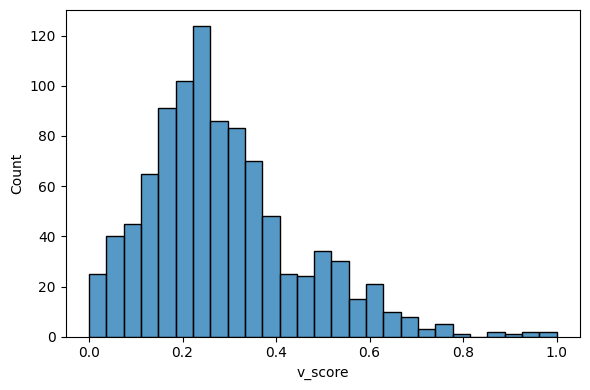

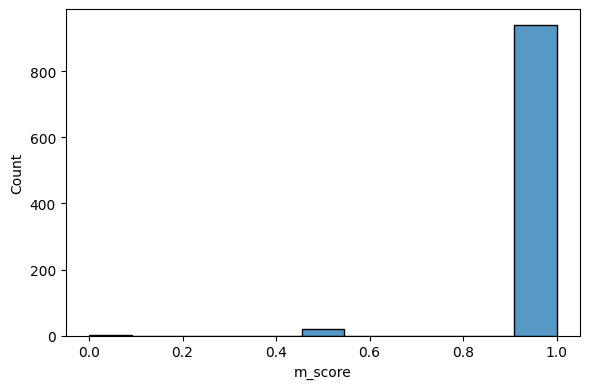

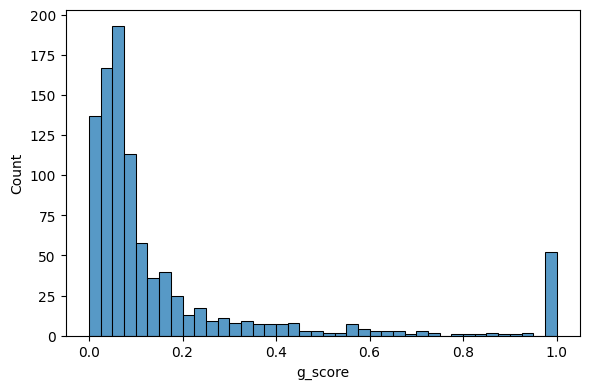

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = ["v_score", "m_score", "g_score"]

for col in target_col:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_unique, x=col, bins='auto')  # bins='auto' 대신 적당한 정수
    plt.tight_layout()
    plt.show()

In [12]:
raw_df['volume']=raw_df['volume'].str.replace(',','')
raw_df['growth']=raw_df['growth'].str.replace(',','')
raw_df['volume']=raw_df['volume'].astype(int)
raw_df['growth']=raw_df['growth'].astype(float)

In [13]:
mapping_df=df_unique[['volume','growth','media','v_score','g_score','m_score']]
df=raw_df.merge(mapping_df, on=['volume','growth','media'], how='left')

In [14]:
df['Alert_date']=pd.to_datetime(df['Alert_date'], format='%Y%m%d%H%M')
df['day']=df['Alert_date'].dt.day
df['hour']=df['Alert_date'].dt.hour
df=df.drop(['volume','media','growth', 'Alert_date'], axis=1)



In [15]:
days=[i for i in range(20,30)]
hour_dict={'dawn':[0,1,2,3,4,5],
           'b_n':[6,7,8,9,10,11],
           'a_n':[12,13,14,15,16,17],
           'night':[18,19,20,21,22,23]}

In [16]:
df_labeled=df.copy()

In [17]:
df_labeled['scoring']=0.2*df_labeled['v_score']+0.4*df_labeled['g_score']+0.4*df_labeled['m_score']

In [ ]:
df_labeled['is_0.4score'] = (df_labeled['scoring'] >= 0.4).astype(int)
df_labeled['is_0.5score'] = (df_labeled['scoring'] >= 0.5).astype(int)
df_labeled['is_0.6score'] = (df_labeled['scoring'] >= 0.6).astype(int)
df_labeled['is_0.7score'] = (df_labeled['scoring'] >= 0.7).astype(int)


In [20]:
df_labeled.to_excel('df_labeld.xlsx', header=True)

In [21]:
days=[i for i in range(20,30)]
hour_dict={'dawn':[0,1,2,3,4,5],
           'b_n':[6,7,8,9,10,11],
           'a_n':[12,13,14,15,16,17],
           'night':[18,19,20,21,22,23]}

In [22]:
def get_time_zone(hour):
    if hour in [0, 1, 2, 3, 4, 5]:
        return 'dawn'
    elif hour in [6, 7, 8, 9, 10, 11]:
        return 'b_n'
    elif hour in [12, 13, 14, 15, 16, 17]:
        return 'a_n'
    elif hour in [18, 19, 20, 21, 22, 23]:
        return 'night'
    else:
        return 'unknown'

In [23]:
df_labeled['time_zone'] = df_labeled['hour'].apply(get_time_zone)

In [25]:
sampled_df = df_labeled.groupby(['day', 'time_zone']).apply(lambda x: x.sample(n=20, replace=True)).reset_index(drop=True)

C:\Users\이진섭\AppData\Local\Temp\ipykernel_25984\1960887409.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_labeled.groupby(['day', 'time_zone']).apply(lambda x: x.sample(n=20, replace=True)).reset_index(drop=True)


In [26]:
len(raw_df)

7225

In [28]:
len(sampled_df)

700

In [29]:
sampled_df=sampled_df.drop(['v_score','g_score','m_score','day','hour'], axis=1)

In [30]:
sampled_df.drop('time_zone', axis=1, inplace=True)

In [31]:
sampled_df.to_excel('sample_df.xlsx', header=True)